# NATS: from an M/M/1 queue to two vertiports

1. Learn how a single M/M/1 queue works.
2. Run a fixed fleet between two vertiports.
3. Compare minimum following intervals of 1, 3 and 5 minutes.
4. Inspect departure patterns and stand allocation.
5. Optionally test a timetable and change charging time.

**Units:** minutes, kilometres and km/h. Use a Python 3.9+ kernel.
The default timing values are illustrative assumptions, not measured eVTOL performance.
In particular, five-minute charging is optimistic.

## 1. Set up the notebook

This cell installs **only missing** dependencies into the active Python environment.
If an installation is needed, it requires internet access. SimPy was tested at version 4.1.1.
After installation, the imports below should complete without errors.

In [13]:
import importlib.util
import subprocess
import sys

packages = {"simpy": "simpy==4.1.1", "matplotlib": "matplotlib"}
missing = [package for name, package in packages.items()
           if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import math
import random
from dataclasses import asdict, dataclass, replace
from statistics import mean
from html import escape

import simpy
import matplotlib.pyplot as plt
from IPython.display import display, HTML

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("Ready. SimPy version:", simpy.__version__)

Ready. SimPy version: 4.1.1


## 2. Understand the M/M/1 model

The first **M** means exponential arrival gaps (Poisson arrivals); the second means exponential
service times. **1** means one server, such as a single pad.

- $\lambda$: arrivals per minute; the mean gap is $1/\lambda$ minutes.
- $\mu$: services per minute; mean service duration is $1/\mu$ minutes.
- $\rho=\lambda/\mu$: utilisation. A steady state requires $\rho<1$.

For that model:

$$W_q=\frac{\lambda}{\mu(\mu-\lambda)}, \qquad
W=\frac{1}{\mu-\lambda}, \qquad L_q=\lambda W_q.$$

$W_q$ is waiting **before** service; $W$ includes service.
For $\lambda=2/3$ and $\mu=1$, the theoretical mean waiting time is **2 minutes**.

This is an isolated teaching example, not the fixed-fleet aircraft system.
[Theory reference (MIT)](https://web.mit.edu/dimitrib/www/Queueing_Data_Nets.pdf).

### Define the queue

This is the same function as in `mm1_demo.py`. Run this cell to define it; the next cell runs it.

`yield request` waits for the pad. `yield env.timeout(...)` lets simulated time pass for this
process while other processes continue. Arrivals stop at the horizon, then the remaining
queue drains, so every recorded arrival has a completed waiting time.

In [14]:
def simulate(arrival_rate=2/3, service_rate=1.0,
             horizon=100000.0, warmup=10000.0, seed=42):
    if not 0 < arrival_rate < service_rate:
        raise ValueError("This demonstration requires a stable queue: 0 < lambda < mu.")
    if not 0 <= warmup < horizon:
        raise ValueError("Require 0 <= warmup < horizon.")
    env = simpy.Environment()
    pad = simpy.Resource(env, capacity=1)
    arrivals_rng = random.Random(seed)
    services_rng = random.Random(seed + 1)
    waits = []

    def operation():
        arrival = env.now
        with pad.request() as request:
            yield request
            if arrival >= warmup:
                waits.append(env.now - arrival)
            yield env.timeout(services_rng.expovariate(service_rate))

    def source():
        while True:
            gap = arrivals_rng.expovariate(arrival_rate)
            if env.now + gap >= horizon:
                return
            yield env.timeout(gap)
            env.process(operation())

    env.process(source())
    env.run()  # Terminates: arrivals eventually stop, then all jobs finish.
    theoretical = arrival_rate / (service_rate * (service_rate-arrival_rate))
    return {"mean_wait_simulated": mean(waits) if waits else None,
            "mean_wait_theoretical": theoretical,
            "rho": arrival_rate/service_rate, "observations": len(waits)}

### Run the queue

You can change the two rates below, keeping `0 < arrival_rate < service_rate`.
The warm-up period reduces the effect of starting with an empty queue.
A random simulation will be close to the formula, not identical to it.

In [15]:
mm1_result = simulate(
    arrival_rate=2/3,
    service_rate=1.0,
    horizon=100000,
    warmup=10000,
    seed=42,
)
print(f"Utilisation: {mm1_result['rho']:.1%}")
print(f"Theoretical mean queue wait: {mm1_result['mean_wait_theoretical']:.3f} min")
print(f"Simulated mean queue wait:   {mm1_result['mean_wait_simulated']:.3f} min")
print(f"Recorded arrivals: {mm1_result['observations']:,}")

Utilisation: 66.7%
Theoretical mean queue wait: 2.000 min
Simulated mean queue wait:   2.066 min
Recorded arrivals: 59,893


### Read these SimPy operations

| Expression | Meaning |
|---|---|
| `simpy.Environment()` | The clock and event scheduler. |
| `env.now` | Current simulated time. |
| `env.process(function(...))` | Start a process alongside other processes. |
| `yield env.timeout(t)` | Pause this process for `t` simulated minutes. |
| `simpy.Resource(env, capacity=1)` | A resource with one simultaneous user. |
| `yield resource.request()` | Wait until a resource allocation is available. |
| `with resource.request() as req:` | Automatically release the resource when the block ends. |
| `resource.count`, `resource.queue` | Inspect allocations and waiting requests. |
| `simpy.Store(env)` | Store objects, such as requested flights. |
| `env.run(until=...)` | Run to a time limit or stopping event. |

`yield` and `with` are Python syntax. `random.expovariate(rate)` is from Python's `random`
module. It creates a **random gap with a given mean**, not a minimum separation.

[SimPy introduction](https://simpy.readthedocs.io/en/stable/simpy_intro/basic_concepts.html)
· [Resources](https://simpy.readthedocs.io/en/stable/topical_guides/resources.html)
· [Python random](https://docs.python.org/3/library/random.html#random.expovariate)

## 3. Define the two-vertiport model

This is a **closed fleet**: the same aircraft repeatedly travel A → B → A.
It is not a textbook M/M/1 system. Keep the M/M/1 example as a separate learning/validation model.

| Input | Baseline |
|---|---|
| Vertiports and distance | A and B, 30 km apart |
| Charging stands | Four per port; one charger on each stand |
| Landing/take-off pad | One shared pad per port |
| Aircraft | Eight, initially charged, four parked at each port |
| Constant speed | 180 km/h; flight time = 10 min |
| Take-off and landing | 0.5 min each |
| Taxi out and taxi in | 0.5 min each |
| Unloading and boarding | 0.5 min each, sequential with charging |
| Charging | 5 min; an optimistic placeholder |
| Following interval | At least 1, 3 or 5 min on each directed route |

At 180 km/h, the following gaps correspond to 3, 9 and 15 km while both aircraft cruise at
that speed. Opposite directions are assumed to have separate, non-interacting corridors.
The model does not simulate battery energy, weather, passengers or conflicts with other traffic.

Aircraft keep their stand until departure. Arriving aircraft reserve a stand before using the
pad; if no stand is available they hold airborne. **Allocated stands include reservations**
during landing and taxi-in. The pad is conservatively blocked during taxi to/from it.

**Minimum following gap is not guaranteed frequency.** If no aircraft is ready, the gap grows.
The optional timetable later tests whether an exact target frequency can be sustained.

### Parameter definitions

Run this cell. You will change the scenario in the small **Edit your experiment here** cell
below, so you do not need to edit the class definition.

In [16]:
@dataclass
class Parameters:
    headway: float = 5.0          # Minimum following gap on EACH directed route.
    fleet: int = 8               # Start charged: four at A and four at B.
    stands: int = 4              # Per port; every stand has its own charger.
    distance_km: float = 30.0
    speed_kmh: float = 180.0
    takeoff: float = 0.5
    landing: float = 0.5
    taxi_out: float = 0.5
    taxi_in: float = 0.5
    unload: float = 0.5
    charge: float = 5.0
    board: float = 0.5
    horizon: float = 1440.0      # Finite upper limit: one simulated day.
    warmup: float = 120.0       # Used only for the reported throughput.
    max_delay: float = 30.0     # Operational threshold, not a crash prediction.
    max_holding: float = 10.0   # Operational threshold; energy is not modelled.
    monitor_interval: float = 0.25
    random_charge: bool = False
    seed: int = 42
    timetable: bool = False     # Optional test of sustaining an exact target rate.

    @property
    def flight_time(self):
        return 60 * self.distance_km / self.speed_kmh

    @property
    def departure_duration(self):
        return self.taxi_out + self.takeoff

    @property
    def minimum_round_trip(self):
        return 2 * (self.flight_time + self.landing + self.taxi_in
                    + self.unload + self.charge + self.board
                    + self.departure_duration)

### Aircraft and vertiport processes

This is the same `ShuttleModel` class as in `two_vertiports.py`, without command-line handling.
Run it once to define the model. You can leave this long cell collapsed while experimenting.

The main lifecycle is in `aircraft()`: departure → flight → arrival → turnaround → repeat.
`monitor()` checks unfinished waiting times and resource limits.

An operational threshold is crossed when departure waiting/delay exceeds **30 min** or
airborne holding exceeds **10 min**. These are adjustable toy limits, not crash predictions.
Monitoring runs every 0.25 min, so detection may lag slightly. Simulation ends at the first
recorded crossing or the finite horizon; a successful finite run is not proof for infinity.

In [17]:
class ShuttleModel:
    def __init__(self, p):
        if not 1 <= p.fleet <= 2 * p.stands:
            raise ValueError("This initialisation requires 1 <= fleet <= total stands.")
        if min(p.headway, p.speed_kmh, p.distance_km, p.horizon,
               p.monitor_interval, p.max_delay, p.max_holding) <= 0:
            raise ValueError("Headway, distance, speed, horizon and thresholds must be positive.")
        if min(p.takeoff, p.landing, p.taxi_out, p.taxi_in,
               p.unload, p.charge, p.board, p.warmup) < 0:
            raise ValueError("Durations cannot be negative.")
        if p.departure_duration <= 0 or p.landing + p.taxi_in <= 0:
            raise ValueError("Each pad operation must occupy a positive duration.")
        self.p = p
        self.env = simpy.Environment()
        self.pad = {x: simpy.Resource(self.env, capacity=1) for x in "AB"}
        self.stand = {x: simpy.Resource(self.env, capacity=p.stands) for x in "AB"}
        # The gate serialises departure clearance; it is not a physical extra pad.
        self.gate = {x: simpy.Resource(self.env, capacity=1) for x in "AB"}
        self.jobs = {x: simpy.Store(self.env) for x in "AB"}
        self.pending = {x: {} for x in "AB"}
        self.last_takeoff = {x: -math.inf for x in "AB"}
        self.state = {}
        self.holding_since = {}
        self.departures = []
        self.arrivals = []
        self.holding_times = []
        self.pad_uses = []
        self.history = []
        self.failure = self.env.event()
        self.failure_time = None
        self.failure_reason = None

    def timetable(self, port):
        """Issue one request per headway, without creating an aircraft."""
        sequence = 0
        while True:
            # Release the job one departure-operation duration before its due time.
            due = self.env.now + self.p.departure_duration
            self.pending[port][sequence] = due
            yield self.jobs[port].put((sequence, due))
            sequence += 1
            yield self.env.timeout(self.p.headway)

    def aircraft(self, aircraft_id, start_port):
        env, p = self.env, self.p
        rng = random.Random(p.seed + 1009 * aircraft_id)
        port = start_port
        # The aircraft owns this stand until it physically leaves for the pad.
        stand_token = self.stand[port].request()
        yield stand_token
        while True:
            self.state[aircraft_id] = "ready_" + port
            if p.timetable:
                job_id, due = yield self.jobs[port].get()
            else:
                # Ready aircraft request departure; no external aircraft or
                # flight requests are generated in the default closed model.
                job_id = aircraft_id
                due = env.now + p.departure_duration
                self.pending[port][job_id] = due
            self.state[aircraft_id] = "departure_queue_" + port

            with self.gate[port].request() as clearance:
                yield clearance
                earliest_start = max(due, self.last_takeoff[port] + p.headway)
                earliest_start -= p.departure_duration
                yield env.timeout(max(0.0, earliest_start - env.now))

                with self.pad[port].request() as pad_token:
                    yield pad_token
                    start = env.now
                    self.stand[port].release(stand_token)
                    self.state[aircraft_id] = "departing_" + port
                    # Conservatively block the pad while taxiing to/from it.
                    yield env.timeout(p.taxi_out)
                    yield env.timeout(p.takeoff)
                    self.last_takeoff[port] = env.now
                    self.pending[port].pop(job_id)
                    self.departures.append({"aircraft": aircraft_id, "port": port,
                                            "time": env.now, "due": due,
                                            "delay": env.now - due})
                    if env.now - due > p.max_delay:
                        self.record_failure("A departure exceeded the waiting/delay limit.")
                    self.pad_uses.append((port, "departure", start, env.now))

            destination = "B" if port == "A" else "A"
            self.state[aircraft_id] = "flying_" + port + "_" + destination
            yield env.timeout(p.flight_time)
            port = destination

            # Wait IN THE AIR for a stand, then for the pad. A landing never
            # blocks the pad while waiting for a full parking area to clear.
            self.state[aircraft_id] = "holding_" + port
            self.holding_since[aircraft_id] = env.now
            stand_token = self.stand[port].request()
            yield stand_token
            with self.pad[port].request() as pad_token:
                yield pad_token
                start = env.now
                holding = env.now - self.holding_since.pop(aircraft_id)
                self.holding_times.append(holding)
                if holding > p.max_holding:
                    self.record_failure("An aircraft exceeded the airborne-holding limit.")
                self.state[aircraft_id] = "landing_" + port
                yield env.timeout(p.landing)
                self.arrivals.append({"aircraft": aircraft_id, "port": port,
                                      "time": env.now, "holding": holding})
                yield env.timeout(p.taxi_in)
                self.pad_uses.append((port, "arrival", start, env.now))

            self.state[aircraft_id] = "turnaround_" + port
            yield env.timeout(p.unload)
            charge = (rng.triangular(0.8*p.charge, 1.2*p.charge, p.charge)
                      if p.random_charge and p.charge else p.charge)
            yield env.timeout(charge)
            yield env.timeout(p.board)
            # Do NOT release the stand here: a charged aircraft still occupies it.

    def record_failure(self, reason):
        if not self.failure.triggered:
            self.failure_time = self.env.now
            self.failure_reason = reason
            # 'succeed' means this monitoring event occurred. fail() would raise
            # a Python exception rather than return an ordinary model outcome.
            self.failure.succeed(reason)

    def snapshot(self):
        now = self.env.now
        ages = [max(0.0, now-due) for jobs in self.pending.values()
                for due in jobs.values()]
        airborne_waits = [now-t for t in self.holding_since.values()]
        return {"time": now,
                "pending_A": len(self.pending["A"]),
                "pending_B": len(self.pending["B"]),
                "delayed_departures": sum(now > due + 1e-9
                               for jobs in self.pending.values() for due in jobs.values()),
                "oldest_delay": max(ages, default=0.0),
                "longest_current_holding": max(airborne_waits, default=0.0),
                "stands_A": self.stand["A"].count,
                "stands_B": self.stand["B"].count,
                "pad_queue_A": len(self.pad["A"].queue),
                "pad_queue_B": len(self.pad["B"].queue),
                "completed_flights": len(self.arrivals)}

    def monitor(self):
        while True:
            yield self.env.timeout(self.p.monitor_interval)
            row = self.snapshot()
            self.history.append(row)
            assert len(self.state) == self.p.fleet
            assert all(r.count <= self.p.stands for r in self.stand.values())
            assert all(r.count <= 1 for r in self.pad.values())
            if not self.failure.triggered:
                reason = None
                if row["oldest_delay"] > self.p.max_delay:
                    reason = "A departure request is over the waiting/delay limit."
                if row["longest_current_holding"] > self.p.max_holding:
                    reason = "An aircraft is over the airborne-holding limit."
                if reason:
                    self.record_failure(reason)

    def run(self, stop_on_failure=True):
        if self.p.timetable:
            for port in "AB":
                self.env.process(self.timetable(port))
        for aircraft_id in range(self.p.fleet):
            port = "A" if aircraft_id % 2 == 0 else "B"
            self.state[aircraft_id] = "initialising_" + port
            self.env.process(self.aircraft(aircraft_id, port))
        self.env.process(self.monitor())
        end = self.env.timeout(self.p.horizon)
        self.env.run(until=(self.failure | end) if stop_on_failure else end)

        elapsed = self.env.now - self.p.warmup
        n = sum(self.p.warmup <= a["time"] < self.env.now for a in self.arrivals)
        return {"parameters": asdict(self.p), "end_time": self.env.now,
                "first_failure_time": self.failure_time,
                "failure_reason": self.failure_reason,
                "completed_flights": len(self.arrivals),
                "flights_per_hour_after_warmup": 60*n/elapsed if elapsed > 0 else None,
                "mean_completed_departure_delay": mean(d["delay"] for d in self.departures)
                    if self.departures else None,
                "max_completed_holding": max(self.holding_times, default=0.0),
                "final": self.snapshot(),
                "history": self.history,
                "departures": self.departures,
                "arrivals": self.arrivals,
                "pad_uses": self.pad_uses}

## 4. Edit your experiment here

These defaults reproduce the previous seven-day comparison: the first day is excluded from
the reported throughput. For a faster one-day experiment, use `horizon=1440` and `warmup=120`.

Keep `fleet <= 8` with four stands per port: this version starts all aircraft parked.
That is an initialisation restriction, not a physical maximum fleet size. A larger fleet would
require some aircraft initially airborne or extra staging space.

After changing this cell, rerun the comparison and plotting cells below. Every run creates a
fresh environment; never call `.run()` twice on the same model instance.

In [18]:
HEADWAYS = [1, 3, 5]
BASE = Parameters(
    fleet=8,
    stands=4,
    distance_km=30,
    speed_kmh=180,
    charge=5,
    horizon=7 * 24 * 60,
    warmup=24 * 60,
    max_delay=30,
    max_holding=10,
    random_charge=False,
    seed=42,
    timetable=False,
)
assert 0 <= BASE.warmup < BASE.horizon
print(f"Flight time: {BASE.flight_time:g} min")
print(f"Minimum round trip including both turnarounds: {BASE.minimum_round_trip:g} min")
for h in HEADWAYS:
    required = math.ceil(BASE.minimum_round_trip / h)
    print(f"To sustain a departure every {h} min from EACH port: at least {required} aircraft")
print("These fleet bounds are necessary, not sufficient; pad/stand constraints still apply.")

Flight time: 10 min
Minimum round trip including both turnarounds: 36 min
To sustain a departure every 1 min from EACH port: at least 36 aircraft
To sustain a departure every 3 min from EACH port: at least 12 aircraft
To sustain a departure every 5 min from EACH port: at least 8 aircraft
These fleet bounds are necessary, not sufficient; pad/stand constraints still apply.


### Run and compare the three following intervals

The displayed rate counts landed, one-way flights in **both directions**, after warm-up.
Remaining requests and completed waits describe the final state/all-run history, respectively.
In the closed model, requests come only from ready aircraft. In timetable mode, requests
can accumulate without creating more aircraft.

In [19]:
def show_summary(results):
    headers = ["Minimum gap (min)", "End time (min)", "Landed flights (all run)",
               "Flights/hour after warm-up", "First threshold (min)",
               "Unserved requests at end"]
    rows = []
    for result in results:
        rate = result["flights_per_hour_after_warmup"]
        failure = result["first_failure_time"]
        rows.append([
            f'{result["parameters"]["headway"]:g}',
            f'{result["end_time"]:.2f}',
            str(result["completed_flights"]),
            f'{rate:.2f}' if rate is not None else "n/a: stopped before warm-up ended",
            f'{failure:.2f}' if failure is not None else "None observed",
            str(result["final"]["pending_A"] + result["final"]["pending_B"]),
        ])
    table = "<table><thead><tr>" + "".join(f"<th>{escape(h)}</th>" for h in headers)
    table += "</tr></thead><tbody>"
    for row in rows:
        table += "<tr>" + "".join(f"<td>{escape(value)}</td>" for value in row) + "</tr>"
    display(HTML(table + "</tbody></table>"))

closed_results = []
for h in HEADWAYS:
    parameters = replace(BASE, headway=h, timetable=False)
    result = ShuttleModel(parameters).run(stop_on_failure=True)
    closed_results.append(result)

show_summary(closed_results)

Minimum gap (min),End time (min),Landed flights (all run),Flights/hour after warm-up,First threshold (min),Unserved requests at end
1,10080.00,4480,26.67,None observed,2
3,10080.00,4478,26.67,None observed,2
5,10080.00,4028,24.00,None observed,2


### See the actual departure pattern

Each mark is a take-off from A during the first 80 minutes. With the supplied defaults,
one-minute separation gives bursts with gaps `1, 1, 1, 15`; three-minute separation gives
`3, 3, 3, 9`. Five-minute separation gives regular five-minute gaps.
The first two cases are limited by aircraft circulation rather than their minimum gap.
Changing the parameters can change these patterns.

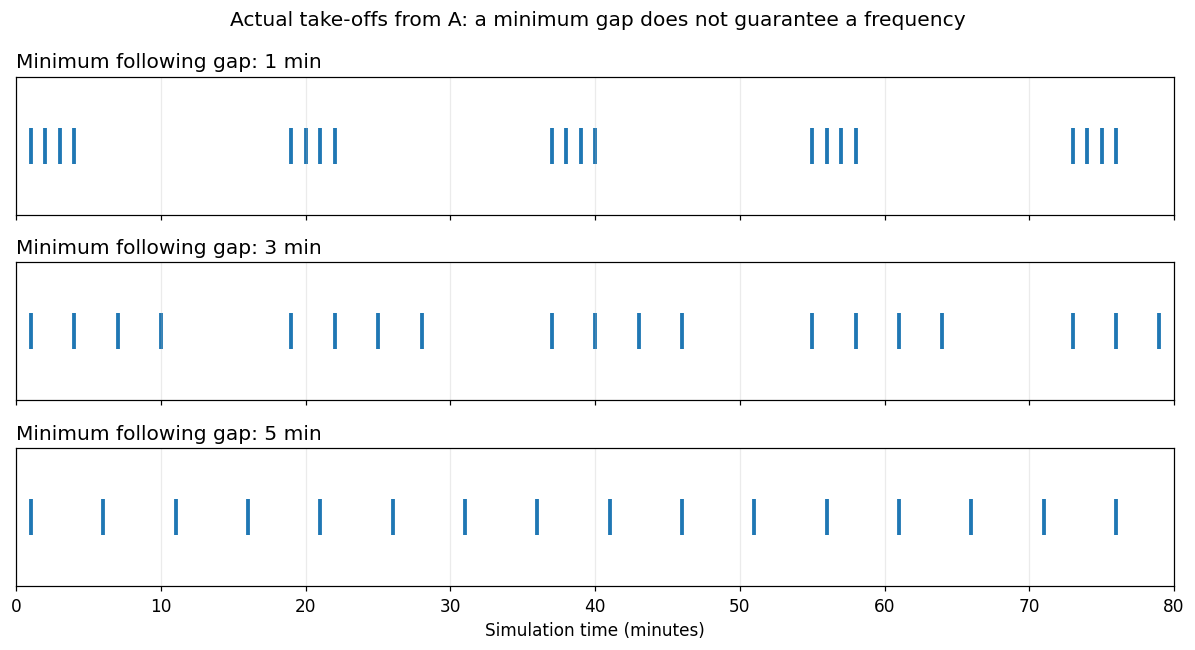

In [20]:
fig, axes = plt.subplots(len(closed_results), 1, figsize=(11, 2.0*len(closed_results)),
                         sharex=True, squeeze=False)
for ax, result in zip(axes[:, 0], closed_results):
    h = result["parameters"]["headway"]
    times = [d["time"] for d in result["departures"]
             if d["port"] == "A" and d["time"] <= 80]
    ax.scatter(times, [0]*len(times), marker="|", s=550, linewidths=2.5)
    ax.set_title(f"Minimum following gap: {h:g} min", loc="left")
    ax.set_yticks([])
    ax.set_ylim(-0.5, 0.5)
    ax.grid(axis="x", alpha=0.25)
axes[-1, 0].set_xlim(0, 80)
axes[-1, 0].set_xlabel("Simulation time (minutes)")
fig.suptitle("Actual take-offs from A: a minimum gap does not guarantee a frequency")
fig.tight_layout()
plt.show()

### Inspect the four-stand constraint

These curves show **reserved plus physically occupied** stands. They do not measure how
many chargers are drawing power. A charged aircraft waiting to depart still occupies a stand.

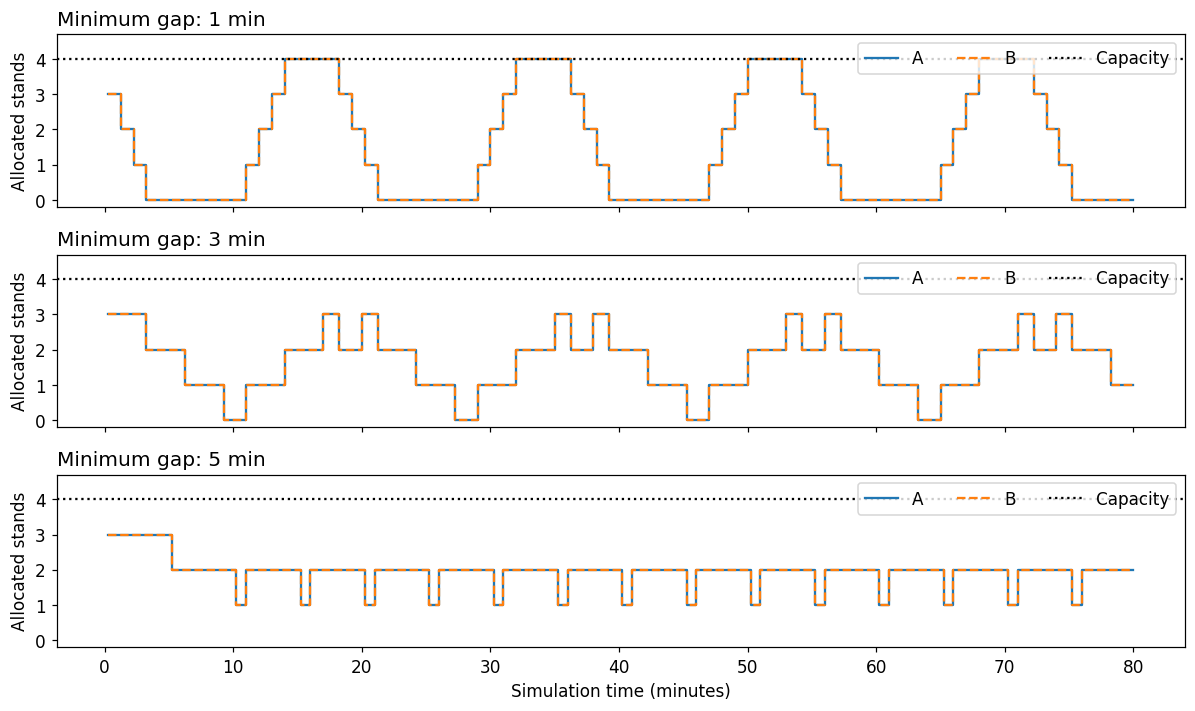

In [21]:
fig, axes = plt.subplots(len(closed_results), 1, figsize=(11, 2.2*len(closed_results)),
                         sharex=True, squeeze=False)
for ax, result in zip(axes[:, 0], closed_results):
    rows = [row for row in result["history"] if row["time"] <= 80]
    times = [row["time"] for row in rows]
    ax.step(times, [row["stands_A"] for row in rows], where="post", label="A")
    ax.step(times, [row["stands_B"] for row in rows], where="post", label="B", linestyle="--")
    capacity = result["parameters"]["stands"]
    ax.axhline(capacity, color="black", linestyle=":", label="Capacity")
    ax.set_ylim(-0.2, capacity+0.7)
    ax.set_yticks(range(capacity+1))
    ax.set_ylabel("Allocated stands")
    ax.set_title(f'Minimum gap: {result["parameters"]["headway"]:g} min', loc="left")
    ax.legend(loc="upper right", ncol=3)
axes[-1, 0].set_xlabel("Simulation time (minutes)")
fig.tight_layout()
plt.show()

## 5. Optional: require a flight every interval

This adds a timetable requesting one flight every `h` minutes **from each port**.
The fleet still stays fixed. Unserved requests wait; new aircraft are not created.

With the original parameters, the one- and three-minute timetables cross the departure-delay
limit, while the five-minute timetable lasts the whole horizon. Early failures have no
post-warm-up throughput estimate.

To study continuing backlog growth, change `stop_on_failure=True` to `False`. Keep a finite
horizon: a run with continuing event generators will not finish if given no end condition.

In [22]:
timetable_results = []
for h in HEADWAYS:
    parameters = replace(BASE, headway=h, timetable=True)
    result = ShuttleModel(parameters).run(stop_on_failure=True)
    timetable_results.append(result)
show_summary(timetable_results)
for result in timetable_results:
    if result["failure_reason"]:
        print(f'Gap {result["parameters"]["headway"]:g} min: {result["failure_reason"]}')

Minimum gap (min),End time (min),Landed flights (all run),Flights/hour after warm-up,First threshold (min),Unserved requests at end
1,43.25,16,n/a: stopped before warm-up ended,43.25,64
3,103.25,42,n/a: stopped before warm-up ended,103.25,22
5,10080.00,4028,24.00,None observed,2


Gap 1 min: A departure request is over the waiting/delay limit.
Gap 3 min: A departure request is over the waiting/delay limit.


## 6. Optional: change one assumption

This example changes charging to **10 minutes**, retaining the five-minute minimum following
gap and other baseline inputs. Compare its throughput with the earlier five-minute-gap case.
For illustrative variability, set `random_charge=True`: charging is then triangular between
80% and 120% of the specified duration, with the mode at that duration.

Changing one input at a time makes the cause of a result easier to understand. Later, compare
multiple random seeds and report uncertainty instead of relying on a single random run.

In [23]:
alternative = replace(BASE, headway=5, charge=10, timetable=False)
alternative_result = ShuttleModel(alternative).run(stop_on_failure=True)
show_summary([alternative_result])

Minimum gap (min),End time (min),Landed flights (all run),Flights/hour after warm-up,First threshold (min),Unserved requests at end
5,10080.00,3504,20.88,None observed,0


## 7. Check the simulation constraints

These checks verify the following gaps, pad non-overlap, finite stand allocation, and matching
aircraft identities between take-offs and landings in the runs above. They do not establish
real-world operational safety. The original Python package also includes a fuller test suite.

In [24]:
all_results = closed_results + timetable_results + [alternative_result]
for result in all_results:
    p = result["parameters"]
    for row in result["history"]:
        assert 0 <= row["stands_A"] <= p["stands"]
        assert 0 <= row["stands_B"] <= p["stands"]
        if not p["timetable"]:
            assert row["pending_A"] + row["pending_B"] <= p["fleet"]
    for port in "AB":
        times = [d["time"] for d in result["departures"] if d["port"] == port]
        assert all(b-a >= p["headway"]-1e-8 for a, b in zip(times, times[1:]))
        uses = sorted([u for u in result["pad_uses"] if u[0] == port], key=lambda u:u[2])
        assert all(a[3] <= b[2]+1e-8 for a, b in zip(uses, uses[1:]))
    for aircraft_id in range(p["fleet"]):
        departures = [d for d in result["departures"] if d["aircraft"] == aircraft_id]
        arrivals = [a for a in result["arrivals"] if a["aircraft"] == aircraft_id]
        assert len(departures)-len(arrivals) in (0, 1)
        for departure, arrival in zip(departures, arrivals):
            assert departure["port"] != arrival["port"]
            flight_time = 60*p["distance_km"]/p["speed_kmh"]
            assert arrival["time"]-departure["time"] >= flight_time+p["landing"]-1e-8
print(f"Constraint checks passed for all {len(all_results)} runs.")

Constraint checks passed for all 7 runs.


## What to do next

Keep the basic model unchanged while checking assumptions. Compare charging time and fleet
size, then decide what realistic uncertainty or constraints to add. Define what counts as
acceptable delay and throughput before declaring a scenario successful.

Remember that an eight-aircraft closed system cannot grow an infinite aircraft queue. A
finite queue is not evidence that a target frequency is being met. In the timetable experiment,
flight requests can grow without bound even though the aircraft fleet remains fixed.

The same mathematical model and process code as the supplied Python scripts is embedded in
this notebook. The plots and results are generated by its cells; no local project files are
needed. Restart the kernel and run all cells to reproduce a clean run.